In [166]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [167]:
DEBUG = False

# 1. Набор данных

In [168]:
path = './Titanic-Dataset.csv'
data = pd.read_csv(path, sep=',')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [169]:
scaler = StandardScaler()

data = data.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1)
data['Sex'] = data['Sex'].astype('category').cat.codes
data['Age'] = data['Age'].fillna(data['Age'].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])
data['Embarked'] = data['Embarked'].astype('category').cat.codes

X = data.drop("Survived", axis=1)
y = np.where(data["Survived"] == 0, -1, 1)

X_normalized = scaler.fit_transform(X)

X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

X_train_val, X_test, y_train_val, y_test = train_test_split(X_normalized.to_numpy(), y, test_size=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3, random_state=42)

print(f'Размер тренировочной выборки: {X_train.shape}')
print(f'Размер валидационной выборки: {X_val.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

Размер тренировочной выборки: (467, 7)
Размер валидационной выборки: (201, 7)
Размер тестовой выборки: (223, 7)


# 2. Алгоритм

### 2.1. Линейная регрессия с гребневой регуляризацией

In [170]:
class RidgeBinaryClassifier:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.weights = None

    def fit(self, X, y):
        n_features = X.shape[1]
        I = np.eye(n_features)
        self.weights = np.linalg.inv(X.T @ X + self.alpha * I) @ X.T @ y

    def predict(self, X):
        y_pred = X @ self.weights
        return np.sign(y_pred)

### 2.2. Линейная классификация с градиентным спуском

l1 - LASSO

l2 - Ridge

## ElasticNet

$
L_{\tau}(w) = L(w) + l1_{ratio} * \tau * w + (1 - l1_{ratio}) * \frac{1}{2} * \tau * w^2
$;

$
\nabla L_{\tau}(w) = \nabla L(w) + l1_{ratio} * \tau * sign(w) + (1 - l1_{ratio}) * \tau * w
$;

$
w_{k+1} = w_{k} - \mu \nabla L_{\tau}(w_{k}) = w_{k} - \mu \nabla L(w_{k}) - \mu * l1_{ratio} * \tau * sign(w_{k}) - \mu * (1 - l1_{ratio}) * \tau * w_{k}
$;

$
w_{k+1} = w_{k}*(1 - \mu * (1 - l1_{ratio}) * \tau * w_{k}) - \mu * l1_{ratio} * \tau * sign(w_{k}) - \mu \nabla L(w_{k})
$;


In [171]:
class LinearClassifierGD:
    def __init__(self, loss_function='hinge', learning_rate=0.01, max_iter=4000, alpha=1, l1_ratio=0.5):
        self.loss_function = loss_function
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.weights = None
        self.train_risks = []
        self.test_accuracies = []

    def _compute_loss_and_gradient(self, X, y):
        margins = y * (X @ self.weights)

        # LOSS
        if self.loss_function == 'perceptron':
            mask = margins < 0
            loss = np.maximum(np.zeros(margins.shape[0]), -margins).mean()
            gradient = -np.sum((mask[:, np.newaxis] * y[:, np.newaxis] * X), axis=0)
        elif self.loss_function == 'hinge':
            mask = margins < 1
            loss = np.mean(np.maximum(np.zeros(margins.shape[0]), 1 - margins))
            gradient = -np.sum((mask[:, np.newaxis] * y[:, np.newaxis] * X), axis=0)
        elif self.loss_function == 'sigmoid':
            loss = np.mean(2 / (1 + np.exp(margins)))
            exp_margins = np.exp(margins)[:, np.newaxis]
            gradient = np.sum(-2 * (1 + exp_margins) ** (-2) * exp_margins * X * y[:, np.newaxis], axis=0)
        else:
            raise ValueError("Неизвестная функция потерь.")

        # Elastic Net регуляризация
        l1_term = self.l1_ratio * np.sign(self.weights)
        l2_term = (1 - self.l1_ratio) * self.weights
        gradient += self.alpha * (l1_term + l2_term)

        return loss, gradient

    def fit(self, X, y, X_test=None, y_test=None):
        self.train_risks = []
        self.test_accuracies = []

        # Добавляем столбец -1 к X для учета bias
        X = np.hstack([X, -np.ones((X.shape[0], 1))])

        n_features = X.shape[1]
        self.weights = np.zeros(n_features)

        for iteration in range(self.max_iter):
            loss, gradient = self._compute_loss_and_gradient(X, y)
            self.weights -= self.learning_rate * gradient
            self.train_risks.append(loss)

            if X_test is not None and y_test is not None:
                test_accuracy = np.mean(self.predict(X_test) == y_test)
                self.test_accuracies.append(test_accuracy)

            if iteration % 100 == 0:
                if DEBUG:
                    print(f"Итерация {iteration}, Потери: {loss:.4f}")

    def predict(self, X):
        X = np.hstack([X, -np.ones((X.shape[0], 1))])
        return np.sign(X @ self.weights)


### 2.3. Метод опорных векторов с градиентным спуском или SMO

In [172]:
class SVM:
    def __init__(self, kernel='linear', C=1.0, tol=1e-3, max_iter=10, max_passes=5, degree=3, gamma=0.5):
        self.C = C
        self.tol = tol
        self.max_iter = max_iter
        self.max_passes = max_passes
        self.kernel = kernel  # Тип ядра: 'linear', 'poly', 'rbf'
        self.degree = degree  # для poly ядра
        self.gamma = gamma  # для rbf ядра

        self.X = None
        self.y = None
        self.b = None
        self.alphas = None

        self.train_risks = []
        self.test_accuracies = []

    def _kernel_function(self, x1, x2):
        if self.kernel == 'linear':
            return np.dot(x1, x2)
        elif self.kernel == 'poly':
            return (1 + np.dot(x1, x2)) ** self.degree
        elif self.kernel == 'rbf':
            return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)
        else:
            raise ValueError("Unsupported kernel type")

    def _select_random_index(self, i, n_samples):
        j = i
        while j == i:
            j = np.random.randint(0, n_samples)
        return j

    def _compute_margin(self, X, y, K, idx):
        f_xi = np.sum(self.alphas * y * np.array([K[i, idx] for i in range(len(X))])) + self.b
        return f_xi * y[idx]

    def fit(self, X, y, X_test=None, y_test=None):
        n_samples, n_features = X.shape 
        passes = 0
        iteration = 0

        self.train_risks = []
        self.test_accuracies = []
        self.alphas = np.zeros(n_samples)
        self.b = 0
        self.X = X
        self.y = y

        # Предварительное вычисление матрицы ядра
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i, j] = self._kernel_function(X[i], X[j])
    
        while passes < self.max_passes and iteration < self.max_iter:
            num_changed_alphas = 0
            for i in range(n_samples):
                if iteration >= self.max_iter:
                    break

                Ei = self._compute_margin(X, y, K, i)
    
                if (y[i] * Ei < -self.tol and self.alphas[i] < self.C) or (y[i] * Ei > self.tol and self.alphas[i] > 0):
                    j = self._select_random_index(i, n_samples)
                    Ej = self._compute_margin(X, y, K, j)
    
                    # Сохранение старых значений для сравнения
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]
    
                    # Обновление границ
                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])
    
                    if L == H:
                        continue
    
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue
    
                    self.alphas[j] -= y[j] * (Ei - Ej) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)
    
                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue

                    self.alphas[i] += y[i] * y[j] * (alpha_j_old - self.alphas[j])
    
                    # Обновление смещения b
                    b1 = self.b - Ei - y[i] * (self.alphas[i] - alpha_i_old) * K[i, i] - y[j] * (self.alphas[j] - alpha_j_old) * K[i, j]
                    b2 = self.b - Ej - y[i] * (self.alphas[i] - alpha_i_old) * K[i, j] - y[j] * (self.alphas[j] - alpha_j_old) * K[j, j]
    
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2

                    num_changed_alphas += 1

            iteration += 1

            # Эмпирический риск (для предпоследнего графика)
            margins = y * (np.dot(K, self.alphas * y) + self.b)
            risk = np.mean(np.maximum(0, 1 - margins))
            self.train_risks.append(risk)
            
            if iteration % 10 == 0:
                if DEBUG:
                    print(f"Итерация {iteration}, Потери: {risk:.4f}")

            # Проверка точности на тесте (для последнего графика)
            if X_test is not None and y_test is not None:
                test_predictions = self.predict(X_test)
                test_accuracy = np.mean(test_predictions == y_test)
                self.test_accuracies.append(test_accuracy)
    
            if num_changed_alphas == 0:
                passes += 1
            else:
                passes = 0

    def _decision_function(self, x):
        result = np.sum(self.alphas * self.y * np.array([self._kernel_function(x_i, x) for x_i in self.X]))
        return result + self.b

    def predict(self, X):
        return np.sign([self._decision_function(x) for x in X])


# 3.1. Подбор гиперпараметров

In [173]:
def tune_linear_regression(X_train, y_train, X_val, y_val):
    alphas = [0.001, 0.01, 0.1, 1, 10]
    best_alpha = None
    best_score = float('-inf')

    for alpha in alphas:
        model = RidgeBinaryClassifier(alpha=alpha)
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)

        score = accuracy_score(y_val, np.sign(predictions))
        if score > best_score:
            best_score = score
            best_alpha = alpha

    return best_alpha, best_score


In [174]:
def tune_linear_classifier(X_train, y_train, X_val, y_val):
    param_grid = {
        'learning_rate': [0.0001, 0.001, 0.01, 0.1],
        'loss_function': ['perceptron', 'hinge', 'sigmoid'],
        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
        'alpha': [0.001, 0.01, 0.1, 1]
    }

    best_params = None
    best_score = float('-inf')

    for lr in param_grid['learning_rate']:
        for loss in param_grid['loss_function']:
            for l1_ratio in param_grid['l1_ratio']:
                for alpha in param_grid['alpha']:
                    model = LinearClassifierGD(learning_rate=lr, loss_function=loss, l1_ratio=l1_ratio, alpha=alpha)
                    model.fit(X_train, y_train)
                    predictions = model.predict(X_val)

                    score = accuracy_score(y_val, predictions)
                    if score > best_score:
                        best_score = score
                        best_params = (lr, loss, l1_ratio, alpha)

    return best_params, best_score

In [175]:
def tune_svm(X_train, y_train, X_val, y_val):
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'kernel': ['linear', 'poly', 'rbf'],
        'degree': [3, 4, 5],  # Только для poly
        'gamma': [0.01, 0.1, 1]  # Только для rbf
    }

    best_params = None
    best_score = float('-inf')

    # Перебор параметров в сетке
    for C in param_grid['C']:
        for kernel in param_grid['kernel']:
            if kernel == 'poly':
                for degree in param_grid['degree']:
                    model = SVM(kernel=kernel, C=C, degree=degree)
                    model.fit(X_train, y_train)

                    predictions = model.predict(X_val)
                    score = accuracy_score(y_val, predictions)

                    if score > best_score:
                        best_score = score
                        best_params = {'C': C, 'kernel': kernel, 'degree': degree}
            elif kernel == 'rbf':
                for gamma in param_grid['gamma']:
                    model = SVM(kernel=kernel, C=C, gamma=gamma)
                    model.fit(X_train, y_train)

                    predictions = model.predict(X_val)
                    score = accuracy_score(y_val, predictions)

                    if score > best_score:
                        best_score = score
                        best_params = {'C': C, 'kernel': kernel, 'gamma': gamma}
            else:
                model = SVM(kernel=kernel, C=C)
                model.fit(X_train, y_train)

                predictions = model.predict(X_val)
                score = accuracy_score(y_val, predictions)

                if score > best_score:
                    best_score = score
                    best_params = {'C': C, 'kernel': kernel}

    return best_params, best_score


In [176]:
best_params_ridge_regression, score_ridge_regression = tune_linear_regression(X_train, y_train, X_val, y_val)
best_params_linear_classifier, score_linear_classifier = tune_linear_classifier(X_train, y_train, X_val, y_val)
best_params_svm, score_svm = tune_svm(X_train, y_train, X_val, y_val)

In [177]:
print(f"Лучшие гиперпараметры для RidgeRegression: {best_params_ridge_regression} | SCORE: {score_ridge_regression}")
print(f"Лучшие гиперпараметры для LinearClassifierGD: {best_params_linear_classifier} | SCORE: {score_linear_classifier}")
print(f"Лучшие гиперпараметры для SVM: {best_params_svm} | SCORE: {score_svm}")

Лучшие гиперпараметры для RidgeRegression: 0.001 | SCORE: 0.7860696517412935
Лучшие гиперпараметры для LinearClassifierGD: (0.0001, 'sigmoid', 0.0, 0.001) | SCORE: 0.8159203980099502
Лучшие гиперпараметры для SVM: {'C': 1, 'kernel': 'rbf', 'gamma': 0.1} | SCORE: 0.8407960199004975


# 3.2. Построение графиков

In [178]:
def plot_training_learning_curve(train_risks_linear, train_risks_svm):
    plt.figure(figsize=(10, 6))

    # LinearClassifierGD
    iterations = np.arange(1, len(train_risks_linear) + 1)
    plt.plot(iterations, train_risks_linear, label="Эмпирический риск (LinearClassifierGD)",
             color="blue")

    # SVM
    iterations = np.arange(1, len(train_risks_svm) + 1)
    plt.plot(iterations, train_risks_svm, label="Эмпирический риск (SVM)", color="orange")

    plt.xlabel("Итерации")
    plt.ylabel("Эмпирический риск (Тренировка)")
    plt.legend(loc="upper right")
    plt.title("Кривая обучения на тренировочной выборке для LinearClassifierGD и SVM")
    plt.grid(True)
    plt.show()


Лучшие гиперпараметры для RidgeRegression: 0.001 | SCORE: 0.7860696517412935

Лучшие гиперпараметры для LinearClassifierGD: (0.0001, 'sigmoid', 0.0, 0.001) | SCORE: 0.8159203980099502

Лучшие гиперпараметры для SVM: {'C': 1, 'kernel': 'rbf', 'gamma': 0.1} | SCORE: 0.8407960199004975

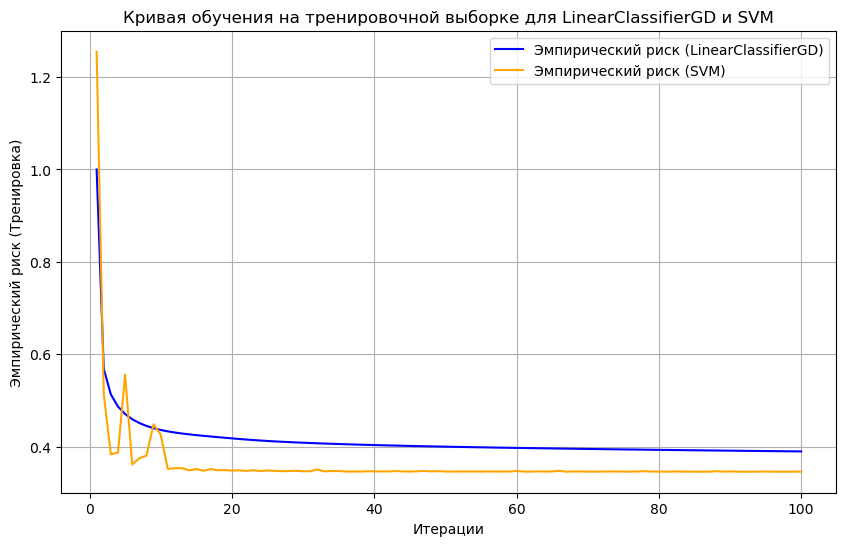

In [179]:
linear_classifier = LinearClassifierGD(loss_function='sigmoid', learning_rate=0.01, l1_ratio=0.0, alpha=0.001, max_iter=100)
linear_classifier.fit(X_train, y_train)
train_risks_linear = linear_classifier.train_risks

svm_classifier = SVM(kernel='rbf', C=1, gamma=0.1, max_iter=100)
svm_classifier.fit(X_train, y_train)
train_risks_svm = svm_classifier.train_risks

plot_training_learning_curve(train_risks_linear, train_risks_svm)

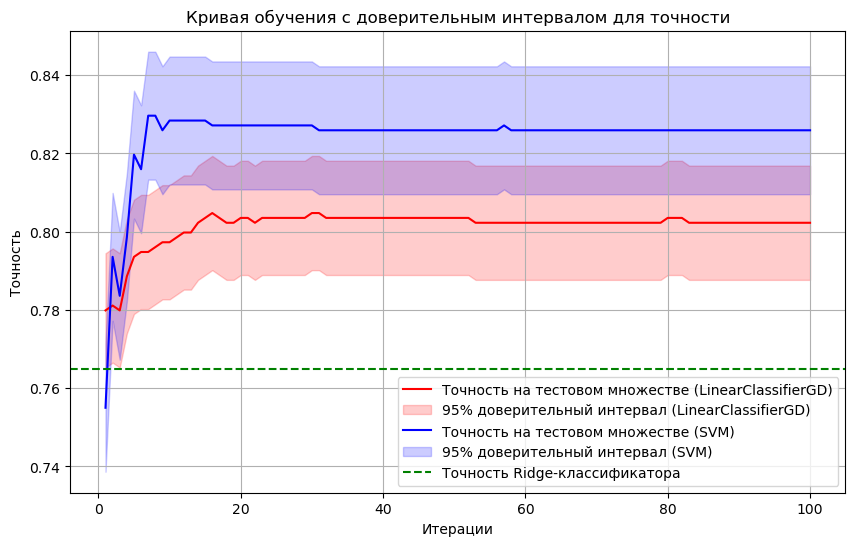

In [183]:
from sklearn.model_selection import train_test_split


def calculate_test_accuracy(model, X_test, y_test):
    predictions = model.predict(X_test)
    return np.mean(predictions == y_test)

def plot_accuracy_learning_curve_with_confidence_interval(test_accuracies_linear, test_accuracies_svm, regression_accuracy):
    plt.figure(figsize=(10, 6))

    iterations = np.arange(1, len(test_accuracies_linear[0]) + 1)

    # LinearClassifierGD
    test_accuracy_linear_mean = np.mean(test_accuracies_linear, axis=0)
    test_accuracy_linear_std = np.std(test_accuracies_linear, axis=0)
    plt.plot(iterations, test_accuracy_linear_mean, label="Точность на тестовом множестве (LinearClassifierGD)", color="red")
    plt.fill_between(iterations,
                     test_accuracy_linear_mean - 1.96 * test_accuracy_linear_std.mean(),
                     test_accuracy_linear_mean + 1.96 * test_accuracy_linear_std.mean(),
                     color="red", alpha=0.2, label="95% доверительный интервал (LinearClassifierGD)")

    # SVM
    test_accuracy_svm_mean = np.mean(test_accuracies_svm, axis=0)
    test_accuracy_svm_std = np.std(test_accuracies_svm, axis=0)
    plt.plot(iterations, test_accuracy_svm_mean, label="Точность на тестовом множестве (SVM)", color="blue")
    plt.fill_between(iterations,
                     test_accuracy_svm_mean - 1.96 * test_accuracy_svm_std.mean(),
                     test_accuracy_svm_mean + 1.96 * test_accuracy_svm_std.mean(),
                     color="blue", alpha=0.2, label="95% доверительный интервал (SVM)")

    plt.axhline(y=regression_accuracy, color='green', linestyle='--', label="Точность Ridge-классификатора")

    plt.xlabel("Итерации")
    plt.ylabel("Точность")
    plt.title("Кривая обучения с доверительным интервалом для точности")
    plt.legend()
    plt.grid()
    plt.show()


num_splits = 3
train_accuracies_linear = []
train_accuracies_svm = []
test_accuracies_linear = []
test_accuracies_svm = []

for _ in range(num_splits):
    X_train, X_test, y_train, y_test = train_test_split(X_normalized.to_numpy(), y, test_size=0.3)

    linear_model = LinearClassifierGD(loss_function='sigmoid', learning_rate=0.01, l1_ratio=0.0, alpha=0.001, max_iter=100)
    svm_model = SVM(kernel='rbf', C=1, gamma=0.1, max_iter=100)

    linear_model.fit(X_train, y_train, X_test, y_test)
    svm_model.fit(X_train, y_train, X_test, y_test)

    test_accuracies_linear.append(linear_model.test_accuracies)
    test_accuracies_svm.append(svm_model.test_accuracies)

ridge_model = RidgeBinaryClassifier(alpha=0.001)
ridge_model.fit(X_train, y_train)
ridge_regression_accuracy = calculate_test_accuracy(ridge_model, X_test, y_test)

plot_accuracy_learning_curve_with_confidence_interval(test_accuracies_linear, test_accuracies_svm, ridge_regression_accuracy)
